# Imports

In [1]:
from langgraph.graph import StateGraph, START, END
#from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

# Loading env variables

In [2]:
import os
load_dotenv()  # Load environment variables from .env file

True

# Define LLM

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=os.environ.get("GEMINI_API_KEY")
)

# Define State

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

# Creating Nodes

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = llm.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

# Define and Compile Graph

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

# Execute the Graph

In [8]:
initial_state = {'title': 'Rise of AI in Bangladesh'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in Bangladesh', 'outline': 'Here\'s a detailed outline for a blog post on "The Rise of AI in Bangladesh," designed to be informative, engaging, and comprehensive.\n\n---\n\n## Blog Title Options:\n\n*   **The Silent Revolution: How AI is Reshaping Bangladesh**\n*   **Bangladesh\'s AI Awakening: Opportunities, Challenges, and the Road Ahead**\n*   **From Digital Bangladesh to Smart Bangladesh: The AI Imperative**\n*   **Beyond the Hype: Understanding the Rise of AI in Bangladesh**\n\n---\n\n## Detailed Blog Outline:\n\n**I. Introduction: Setting the Stage for Bangladesh\'s AI Journey**\n\n*   **A. Hook:**\n    *   Start with a global perspective: AI is transforming industries worldwide, from Silicon Valley to emerging economies.\n    *   Pose a question: "But what about Bangladesh, a nation rapidly embracing its digital future?"\n*   **B. Context: The "Digital Bangladesh" Vision & Its Evolution:**\n    *   Briefly mention the success of "Digital Bangladesh" (intern

In [9]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in Bangladesh," designed to be informative, engaging, and comprehensive.

---

## Blog Title Options:

*   **The Silent Revolution: How AI is Reshaping Bangladesh**
*   **Bangladesh's AI Awakening: Opportunities, Challenges, and the Road Ahead**
*   **From Digital Bangladesh to Smart Bangladesh: The AI Imperative**
*   **Beyond the Hype: Understanding the Rise of AI in Bangladesh**

---

## Detailed Blog Outline:

**I. Introduction: Setting the Stage for Bangladesh's AI Journey**

*   **A. Hook:**
    *   Start with a global perspective: AI is transforming industries worldwide, from Silicon Valley to emerging economies.
    *   Pose a question: "But what about Bangladesh, a nation rapidly embracing its digital future?"
*   **B. Context: The "Digital Bangladesh" Vision & Its Evolution:**
    *   Briefly mention the success of "Digital Bangladesh" (internet penetration, mobile banking, e-governance).
    *   Introduce the next 

In [10]:
print(final_state['content'])

## Bangladesh's AI Awakening: Opportunities, Challenges, and the Road Ahead

The world is in the midst of a technological revolution, one driven by the relentless march of Artificial Intelligence. From the bustling tech hubs of Silicon Valley to the innovative ecosystems of emerging economies, AI is reshaping industries, redefining possibilities, and fundamentally altering how we live and work. But what about Bangladesh, a nation rapidly embracing its digital future? Is it merely an observer, or an active participant in this global transformation?

For years, Bangladesh has championed the "Digital Bangladesh" vision, a strategic initiative that has successfully propelled the nation into the digital age. We've witnessed remarkable strides in internet penetration, mobile banking, e-governance, and the proliferation of digital services. Now, as the nation sets its sights on "Smart Bangladesh 2041," AI is no longer a futuristic concept but the central pillar upon which this ambitious visio

# Visualize Graph (Optional)

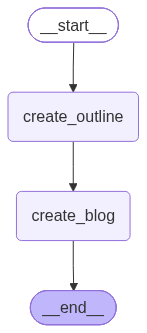

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())